# SBSI tutorial: predicting shear response

This notebook walks through the prediction half of SBSI. You load a trained measurement flow and a blending emulator, hand them a catalogue of galaxies, and get back the shear response of that catalogue — the number you calibrate with.

## 1. Setup

Everything you need is exported from the top-level `sbsi` package. Run this from the repository root with `PYTHONPATH` set, or from anywhere if you installed SBSI with `pip install -e .`.

## 2. Point SBSI at a catalogue

`load_catalogue` reads a Feather, Parquet, CSV, or pickle path.

The catalogue bundled with this notebook is a truth-level input catalogue. It holds about 111,000 galaxies with sky positions (`RA`, `DEC`), a magnitude (`r`), a size (`Re`), a shape (`sersic_n`, `axis_ratio`, `position_angle`), a `redshift`, and the applied shear (`g1`, `g2`).

If you need fresh simulated or measured catalogues, `job_blendemu.sh` in this folder shows how to call BlendEMU's pipeline. SBSI does not render or measure images itself.

In [1]:
from pathlib import Path

from sbsi import (
    EmulatorPairingConfig,
    ModelPaths,
    ResponsePredictor,
    get_model,
    load_catalogue,
    load_emulator,
    prepare_forward_catalogue,
    predict_blend_response,
)

In [2]:
EXAMPLES = Path("examples") if Path("examples").is_dir() else Path(".")
INPUT_CATALOGUE = EXAMPLES / "data/example_catalog.feather"
input_catalogue = load_catalogue(INPUT_CATALOGUE)

input_catalogue.head()

,index,cata_idx,RA,DEC,g1,g2,position_angle,redshift,Re,axis_ratio,sersic_n,r
0,0,773630,180.185728,0.222420,0.0,0.0,164.396647,1.102414,0.162907,0.697792,0.845730,25.733576
1,1,277869,180.118990,0.236218,0.0,0.0,168.168753,0.642087,0.146840,0.341948,0.513552,24.451671
2,2,28030,180.493363,-0.059868,0.0,0.0,91.671930,0.265863,0.396980,0.409923,1.581997,26.839913
3,3,1066306,180.298198,-0.032319,0.0,0.0,152.511604,1.570225,0.155919,0.489980,1.164548,26.660423
4,4,1241052,180.201385,-0.111354,0.0,0.0,41.145542,1.886374,0.192961,0.262081,0.580749,25.564444


## 3. Load the models

In [3]:
# Frozen release paths:
models = get_model("V3")

# An arbitrary model uses the identical workflow:
custom_models = ModelPaths(
    flow_checkpoints=(
        Path("/path/to/models/flow_s1.pt"),
        Path("/path/to/models/flow_s2.pt"),
    ),
    emulator_model=Path("/path/to/models/emulator.json"),
    emulator_metadata=Path("/path/to/models/emulator_metadata.json"),
)

OBSERVING_CONDITIONS = {
    "pixel_size": 0.2,
    "zero_point": 30.0,
    "psf_fwhm": 0.73,
    "moffat_beta": 2.224,
    "pixel_rms": 0.312,
}

models

ModelPaths(flow_checkpoints=(PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s501_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s502_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s503_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s505_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s506_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s507_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s508_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s509_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s510_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s511_swaavg.pt'), PosixPath('models/ablation/measurement_flow_g0_ngmi

## 4. Predict the response

The response has two parts, and you always need both:

$$R_{\mathrm{model}} = R_{\mathrm{flow}} + R_{\mathrm{blend}}.$$

`R_flow` is *self*-response: how an isolated galaxy's measured shape reacts to shear. `R_blend` is the extra response caused by neighbours sitting in the way.

By default `predict` refuses to run if any of your galaxies fall outside the domain, and tells you how many. That is deliberate: extrapolating a flow is not a small error. If you would rather drop those rows and carry on, pass `strict_domain=False`.

In [4]:
# Load the two models. device=None picks CUDA when available and CPU otherwise;
# use a GPU node for production-scale flow prediction.
emulator = load_emulator(models, conditions=OBSERVING_CONDITIONS, device="cpu")
predictor = ResponsePredictor.load(models, device=None)
print("Condition features:", predictor.condition_features)
print("Measured targets:  ", predictor.target_features)
print("Training domain:   ", predictor.domain)

Condition features: ('e1_input_p', 'e2_input_p', 'sersic_n_input_p', 'r_input_p', 'Re_input_p', 'nbr_flux_near', 'nbr_flux_far', 'nbr_flux_max')
Measured targets:   ('measured_ngmix_g1', 'measured_ngmix_g2', 'measured_mag_auto', 'measured_log_flux_radius')
Training domain:    Domain(magnitude_min=18.0, magnitude_max=25.8, half_light_radius_min=0.5, half_light_radius_max=1.5)


`prepare_forward_catalogue` runs the neighbour search and hands back both views as ordinary DataFrames you can inspect:

- `flow_inputs` — one row per galaxy that survived the cuts, indexed by its row number in your original catalogue.
- `emulator_pairs` — one row per accepted pair, so a crowded galaxy shows up several times.

(Working across several fields or tiles? Pass `group_column` so a galaxy is never paired with a "neighbour" from a different field.)

In [5]:
pairing = EmulatorPairingConfig.from_emulator(emulator)
prepared = prepare_forward_catalogue(input_catalogue, config=pairing)
prepared.emulator_pairs[["primary_row", "secondary_row", "distance"]].head()

# The pair-level predictions are summed into a Series keyed by primary_row.
r_blend = predict_blend_response(emulator, prepared.emulator_pairs)

prediction = predictor.predict(
    prepared.flow_inputs,
    blend_response=r_blend,
    shear=0.02,
    n_samples=64,
)
prediction.summary()

sbsi/response.py:196: UserWarning: [blendemu:response] 109874 input rows, extrapolation outside training boundaries:
  sersic_n_input_p: 1762/109874 outside [0.513, 5.85] (input range [0.5, 6])
  sersic_n_input_s: 719/109874 outside [0.513, 5.85] (input range [0.5, 6])
  Predictions for these rows are extrapolations and may be unreliable.
  predicted = emulator.predict_on_pairs(pairs, task="response", rescaled=True)


{'model': 'V3',
 'n_objects': 10265,
 'n_seeds': 16,
 'R_flow': 0.8696021647944042,
 'R_blend': 0.24973616911571508,
 'R_total': 1.1193383339101193,
 'R_flow_seed_sem': 0.0036968274947226385}

### Distribution of the two response channels

`prediction.flow` and `prediction.blend` are per-object arrays: each galaxy's
self response, and the extra response its neighbours contribute. Their
distributions show how the two channels split object by object, beyond the
catalogue means in `prediction.summary()`.

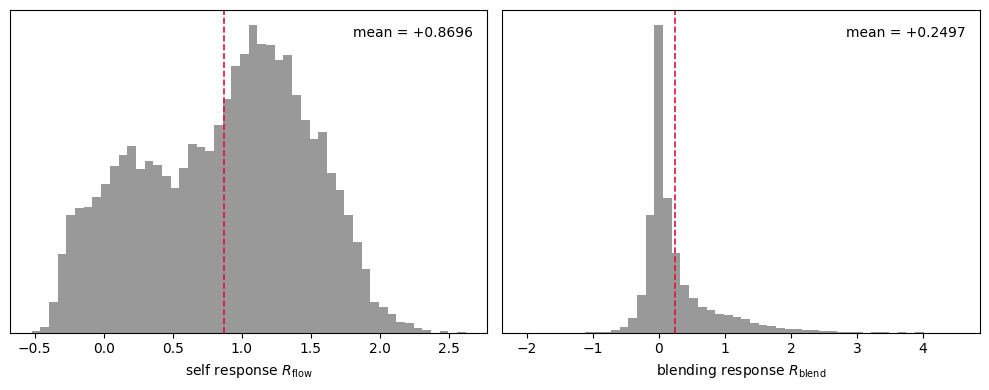

In [6]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
channels = (
    (prediction.flow, r"self response $R_{\mathrm{flow}}$"),
    (prediction.blend, r"blending response $R_{\mathrm{blend}}$"),
)
for ax, (values, label) in zip(axes, channels):
    ax.hist(values, bins=50, color="0.6")
    ax.axvline(values.mean(), color="crimson", ls="--", lw=1.2)
    ax.text(0.97, 0.95, f"mean = {values.mean():+.4f}",
            transform=ax.transAxes, ha="right", va="top")
    ax.set_xlabel(label)
    ax.set_yticks([])
fig.tight_layout()
plt.show()

### The flow's direct output: measured-parameter distributions

`predict` reduces the flow to one number per object, but underneath, the flow
models the joint distribution of *four* measured parameters -- shape
($g_1$, $g_2$), magnitude, and size -- conditioned on each galaxy's input
properties. `sample_measurement` draws that distribution directly: pooled
over the 16-seed ensemble at 256 draws per seed, in physical units. Below,
two contrasted in-domain galaxies (the brightest and the faintest primary);
each row shows the flow-predicted likelihood of its measured shape (left) and
measured magnitude against size (right). The faint galaxy's contours spread
much wider -- the measurement uncertainty the response calculation averages
over.

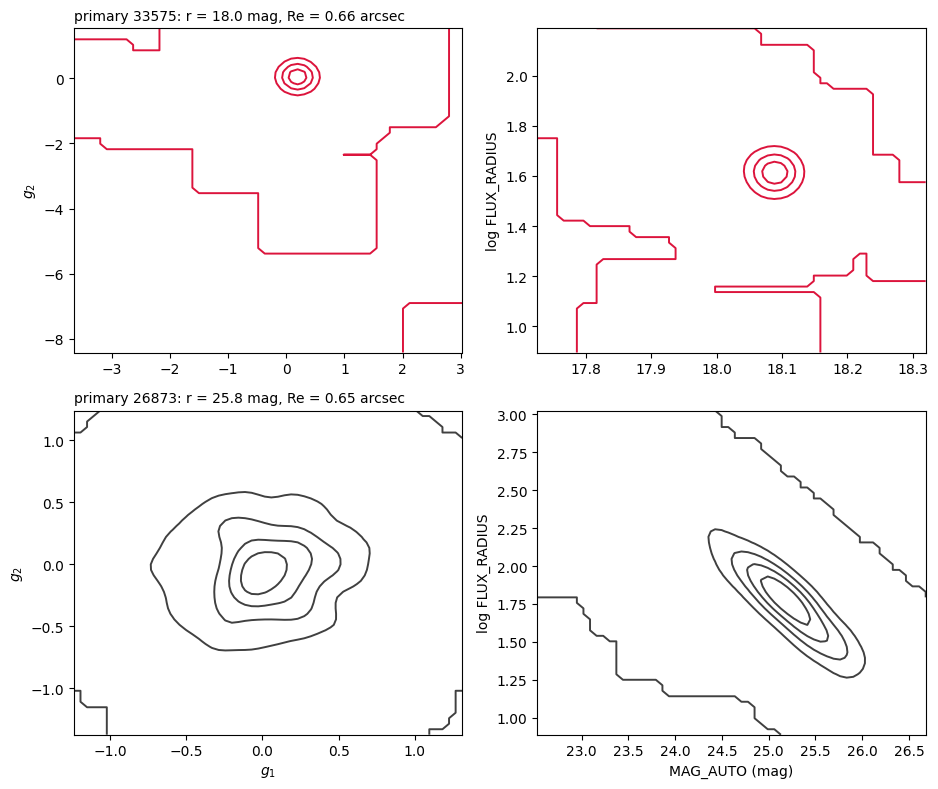

In [7]:
from sbsi import sample_measurement
from scipy import ndimage

bright = prepared.flow_inputs["r_input_p"].idxmin()
faint = prepared.flow_inputs["r_input_p"].idxmax()
rows = prepared.flow_inputs.loc[[bright, faint]]
draw = sample_measurement(models, rows, n_samples=256)

def density_contours(ax, x, y, color):
    counts, xe, ye = np.histogram2d(x, y, bins=60)
    counts = ndimage.gaussian_filter(counts.T, 2.0)
    ax.contour(0.5 * (xe[:-1] + xe[1:]), 0.5 * (ye[:-1] + ye[1:]),
               counts, levels=4, colors=color, linewidths=1.4)

fig, axes = plt.subplots(2, 2, figsize=(9.5, 8))
colors = ("crimson", "0.25")
for ax_row, (primary_row, galaxy), color in zip(axes, rows.iterrows(), colors):
    i = rows.index.get_loc(primary_row)
    density_contours(ax_row[0], draw.column("measured_ngmix_g1")[i],
                     draw.column("measured_ngmix_g2")[i], color)
    density_contours(ax_row[1], draw.column("measured_mag_auto")[i],
                     draw.column("measured_log_flux_radius")[i], color)
    ax_row[0].set_title(
        f"primary {primary_row}: r = {galaxy['r_input_p']:.1f} mag, "
        f"Re = {galaxy['Re_input_p']:.2f} arcsec", fontsize=10, loc="left")
    ax_row[0].set_ylabel("$g_2$")
    ax_row[1].set_ylabel("log FLUX_RADIUS")
axes[1, 0].set_xlabel("$g_1$")
axes[1, 1].set_xlabel("MAG_AUTO (mag)")
fig.tight_layout()
plt.show()

### Detection probability per galaxy

The same BlendEMU suite ships a detection classifier. `predict_detection`
scores every galaxy in a catalogue from its own properties and its single
nearest neighbour, using the classifier's own training aperture: neighbours
are only considered within 3 arcsec, and a galaxy whose nearest neighbour is
farther away takes the classifier's isolated-galaxy branch. We score the full
input catalogue -- faint neighbours affect detection too -- and keep the
retained primaries, which line up with `primary_row`. The response pair table
above cannot be reused here: it spans the regression emulator's 10-arcsec
aperture, outside the classifier's training domain. The remaining warning
covers the small fraction of catalogue galaxies outside the classifier's
trained feature ranges.

In [8]:
detection = emulator.predict_detection(input_catalogue.reset_index(drop=True))
p_detect = detection.loc[prepared.flow_inputs.index, "detection_prob"]
p_detect.describe()

blendemu/inference.py:523: UserWarning: [blendemu:detection] 111210 input rows, extrapolation outside training boundaries:
  Re_input_p_scaled: 2562/111210 outside [0.187, 0.944] (input range [0.0736, 0.994])
  r_input_p_scaled: 157/111210 outside [20.1, 30.1] (input range [14.8, 20.1])
  sersic_n_input_p: 702/111210 outside [0.513, 5.85] (input range [0.5, 6])
  sersic_n_input_s: 431/111210 outside [0.513, 5.85] (input range [0.5, 6])
  distance_scaled: 4/111210 outside [0.000782, 5.59] (input range [5.6, 5.62])
  Predictions for these rows are extrapolations and may be unreliable.
  detection = emulator.predict_detection(input_catalogue.reset_index(drop=True))


count    10265.000000
mean         0.902745
std          0.243655
min          0.000045
25%          0.962567
50%          0.988946
75%          0.996243
max          0.999381
Name: detection_prob, dtype: float64

mean R_total            = 1.1193
mean R_total x P_detect = 1.0225


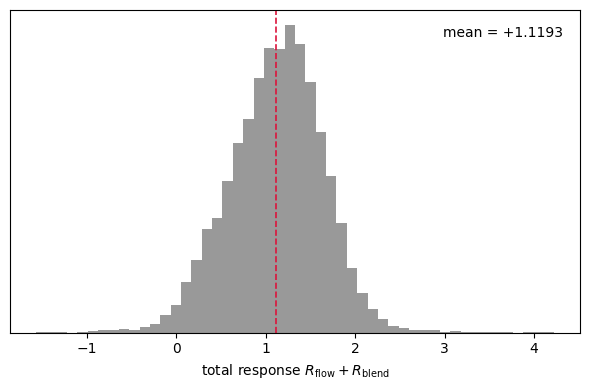

In [9]:
# Total model response per primary, weighted by detection probability.
import pandas as pd

per_primary = pd.DataFrame({
    "R_flow": pd.Series(prediction.flow, index=prediction.index),
    "R_blend": r_blend,
    "P_detect": p_detect,
})
per_primary["R_total"] = per_primary["R_flow"] + per_primary["R_blend"]
per_primary["R_total_detected"] = per_primary["R_total"] * per_primary["P_detect"]
print(
    f"mean R_total            = {per_primary['R_total'].mean():.4f}\n"
    f"mean R_total x P_detect = {per_primary['R_total_detected'].mean():.4f}"
)
# per_primary.head()

# a similar histogram of the total response
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(per_primary["R_total"], bins=50, color="0.6")
mean_total = per_primary["R_total"].mean()
ax.axvline(mean_total, color="crimson", ls="--", lw=1.2)
ax.text(0.97, 0.95, f"mean = {mean_total:+.4f}",
        transform=ax.transAxes, ha="right", va="top")
ax.set_xlabel(r"total response $R_{\mathrm{flow}} + R_{\mathrm{blend}}$")
ax.set_yticks([])
fig.tight_layout()
plt.show()

### Comparing against a simulation

Once you have a matched simulation response, the multiplicative bias is

$$m = R_{\mathrm{sim}} / R_{\mathrm{model}} - 1.$$

```python
m = prediction.multiplicative_bias(simulation_response)
print(f"m = {100 * m:+.3f}%")
```

## 5. Catalogue-level shear inference — not ready yet

The long-term goal is to skip the response-and-bias detour entirely and infer shear directly, putting the measurement flow and the neighbour emulator inside a single simulation-based likelihood.